<a href="https://colab.research.google.com/github/maryamhasnaasyamila/machine-learning/blob/tugas/praktikum/praktikum12/notebooks/Maryam_Hasnaa'_Syamila_0110222067_PraktikumMandiri12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Praktikum Mandiri 12 - Principal Component Analysis (PCA)**
*   **Nama** : Maryam Hasnaa' Syamila
*   **NIM** : 0110222067



#### **Data Preparation**

#### **1. Import Library**

In [1]:
import numpy as np
import pandas as pd

# Library untuk preprocessing dan model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC

# Library evaluasi model
from sklearn.metrics import accuracy_score, classification_report

# Library visualisasi
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Mengatur ukuran default grafik
plt.rcParams['figure.figsize'] = (8, 6)

#### **2. Load Dataset**

In [3]:
# sinkronisasi dengan google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# path dataset di Google Drive
file_path = "/content/drive/My Drive/SEMESTER 7/Machine Learning/praktikum12/datasets/data.csv"

# membaca dataset
df = pd.read_csv(file_path)

# menampilkan 5 baris pertama
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


#### **3. Eksplorasi Awal Dataset (EDA)**

In [5]:
# informasi umum dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [6]:
# statistik deskriptif
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [7]:
# cek missing value
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [8]:
# cek data duplikat
df.duplicated().sum()

np.int64(0)

#### **4. Pemisahan Fitur dan Label**

In [9]:
# Menghapus kolom yang tidak digunakan sebagai fitur
# 'id' dihapus jika ada, dan 'diagnosis' sebagai target
X = df.drop(columns=['diagnosis', 'id'], errors='ignore')

# Label / target
y = df['diagnosis']

print("Shape fitur (X):", X.shape)
print("Shape label (y):", y.shape)

Shape fitur (X): (569, 31)
Shape label (y): (569,)


#### **5. Splitting Data (train/test)**

In [11]:
# Membagi data 80% training dan 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # menjaga proporsi kelas
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (455, 31)
X_test : (114, 31)


#### **6. Standardisasi Data**

In [12]:
# Membuat objek StandardScaler
scaler = StandardScaler()

# Fit dan transform hanya pada data training
X_train_scaled = scaler.fit_transform(X_train)

# Transform data testing menggunakan scaler yang sama
X_test_scaled = scaler.transform(X_test)

# Menampilkan contoh hasil standardisasi
X_train_scaled[:5]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


array([[ 5.18558727e-01,  8.91825791e-01,  4.24631702e-01,
         3.83925436e-01, -9.74743706e-01, -6.89771505e-01,
        -6.88586446e-01, -3.98175254e-01, -1.03915470e+00,
        -8.25056321e-01, -1.09317755e-01, -5.59755400e-02,
        -2.10096206e-01, -1.59132582e-02, -1.00518399e+00,
        -9.11941990e-01, -6.62815884e-01, -6.52561081e-01,
        -7.01889114e-01, -2.75393571e-01,  5.79797697e-01,
         1.31324246e+00,  4.66908134e-01,  4.45982711e-01,
        -5.96154777e-01, -6.34722227e-01, -6.10227299e-01,
        -2.35743918e-01,  5.45663235e-02,  2.18367276e-02,
                    nan],
       [-5.16364088e-01, -1.63971029e+00, -5.41348716e-01,
        -5.42961327e-01,  4.76219058e-01, -6.31833818e-01,
        -6.04281166e-01, -3.03074908e-01,  5.21543093e-01,
        -4.54522896e-01, -6.04377961e-01, -1.00104604e+00,
        -5.85429002e-01, -4.93453793e-01,  4.03212009e-01,
        -7.68173276e-01, -4.79187222e-01,  1.14508478e-01,
        -1.42950761e-01, -5.77

In [15]:
# Cek jumlah NaN di setiap kolom
X.isnull().sum()

,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0
fractal_dimension_mean,0


In [16]:
# Menghapus kolom tidak berguna yang seluruhnya NaN
df = df.drop(columns=['Unnamed: 32'], errors='ignore')

In [18]:
# Menghapus semua kolom yang namanya mengandung 'Unnamed'
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [20]:
# Mengecek jumlah NaN di setiap kolom
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [21]:
# Cek Data yang Masuk ke Model (X)
X = df.drop(columns=['diagnosis', 'id'], errors='ignore')

In [22]:
# Pastikan X sudah bersih dari NaN
X.isnull().sum()

,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0
fractal_dimension_mean,0


#### **Pemisahan Ulang Fitur dan Label**

In [25]:
X = df.drop(columns=['diagnosis', 'id'], errors='ignore')
y = df['diagnosis']

X.isnull().sum()

,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0
fractal_dimension_mean,0


#### **Splitting Data (ulang)**

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#### **Buat ulang StandardScaler**

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [29]:
import numpy as np
np.isnan(X_train_scaled).sum()

np.int64(0)

#### **Model SVM tanpa PCA**

In [30]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

svm_no_pca = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_no_pca.fit(X_train_scaled, y_train)

y_pred_no_pca = svm_no_pca.predict(X_test_scaled)

acc_no_pca = accuracy_score(y_test, y_pred_no_pca)

print("Akurasi SVM tanpa PCA:", acc_no_pca)
print("\nClassification Report (Tanpa PCA)")
print(classification_report(y_test, y_pred_no_pca))

Akurasi SVM tanpa PCA: 0.9736842105263158

Classification Report (Tanpa PCA)
              precision    recall  f1-score   support

           B       0.96      1.00      0.98        72
           M       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



#### **Penerapan PCA**

In [31]:
from sklearn.decomposition import PCA

# Membuat PCA dengan 3 komponen utama
pca = PCA(n_components=3)

# Fit PCA hanya pada data training
X_train_pca = pca.fit_transform(X_train_scaled)

# Transform data testing
X_test_pca = pca.transform(X_test_scaled)

print("Shape X_train_pca:", X_train_pca.shape)
print("Shape X_test_pca :", X_test_pca.shape)

# Variansi yang dijelaskan
explained_var = pca.explained_variance_ratio_
print("Explained Variance Ratio:", explained_var)
print("Total Variansi:", explained_var.sum())


Shape X_train_pca: (455, 3)
Shape X_test_pca : (114, 3)
Explained Variance Ratio: [0.44593522 0.18545255 0.09584641]
Total Variansi: 0.7272341886241546


#### **Visualisasi Explained Variance**

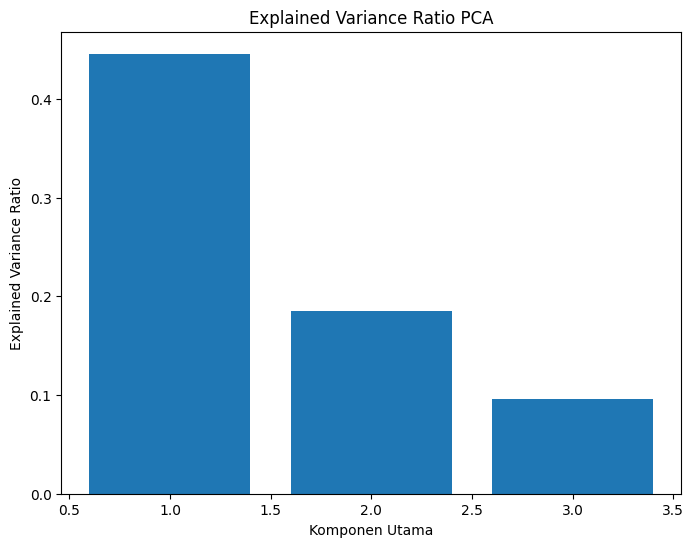

In [32]:
import matplotlib.pyplot as plt

plt.bar([1, 2, 3], explained_var)
plt.xlabel('Komponen Utama')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio PCA')
plt.show()

#### **SVM dengan PCA**

In [33]:
svm_pca = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_pca.fit(X_train_pca, y_train)

y_pred_pca = svm_pca.predict(X_test_pca)

acc_pca = accuracy_score(y_test, y_pred_pca)

print("Akurasi SVM dengan PCA:", acc_pca)
print("\nClassification Report (Dengan PCA)")
print(classification_report(y_test, y_pred_pca))

Akurasi SVM dengan PCA: 0.956140350877193

Classification Report (Dengan PCA)
              precision    recall  f1-score   support

           B       0.94      1.00      0.97        72
           M       1.00      0.88      0.94        42

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114



#### **Kesimpulan Perbandingan**

In [34]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['SVM tanpa PCA', 'SVM dengan PCA'],
    'Jumlah Fitur': [X_train.shape[1], X_train_pca.shape[1]],
    'Akurasi': [acc_no_pca, acc_pca],
    'Total Variansi PCA': [None, explained_var.sum()]
})

comparison

,Model,Jumlah Fitur,Akurasi,Total Variansi PCA
0,SVM tanpa PCA,30,0.973684,NaN
1,SVM dengan PCA,3,0.956140,0.727234
